> # **GRU - Gated Recurrent Unit**

- Simplified advancement of LSTM, where they merge multiple gates into update and reset gates, hence long-term dependencies with faster traning and fewer pareameter.

- Update Gate : how much information from previous hidden state should be retained for the next time step.

- Reset Gate : determines how much of the past hidden state should be forgotten.

- **These gates help GRU to control flow of information.**

> ## **Why We Need GRU (Drawbacks of LSTM)?**

PROBLEM
```

1. Architecture fo LSTM complex due to the complex arch. number of parameter increases

```
```
2. More parameter takes more time in training on large dataset.
```

- So, the solution is GRU -> Simple and less parameter

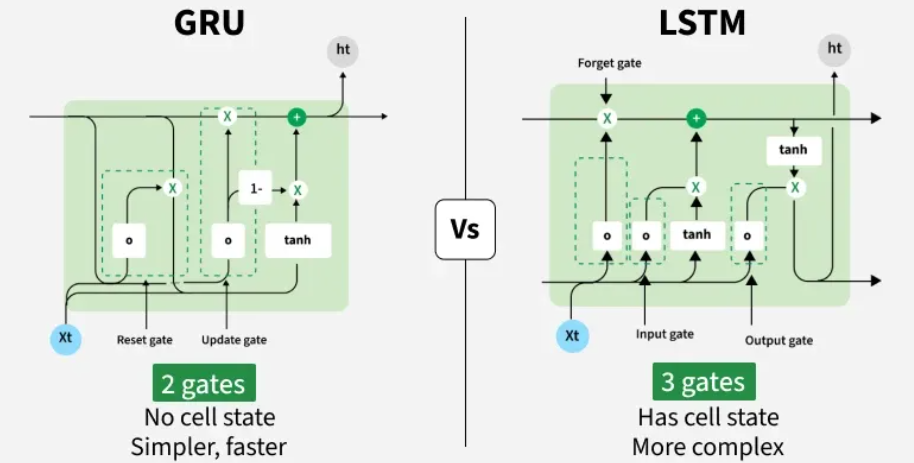

> # **GRU for Text Generation**

> ### Step 1 — Prepare Text Data

In [1]:
text = """ Minimax is a backtracking algorithm used in decision making and game theory to find the optimal
move for a player, assuming that the opponent also plays optimally. It is mainly applied to two-player, turn-based
games where each player tries to outplay the other by making the best
possible decisions. """

> ### Step 2 — Tokenize the data

In [2]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def tokenizing_text(text):
  # split the text into words and associate it with number
  tokenized = Tokenizer()
  tokenized.fit_on_texts([text])

  # creating the vocab by counting
  total_words = len(tokenized.word_index) +1

  print("Total words :", total_words)

  input_sequences = []

  for i in range(1, total_words):
    n_gram_seq = tokenized.texts_to_sequences([text])[0][:i+1]   # This creates prefix sequences only. and cause problem
    print("n_gram_sequences :", n_gram_seq)

    input_sequences.append(n_gram_seq)

  max_len = max(len(sent) for sent in input_sequences)
  print("max_lenth :", max_len)

  # padding the sequences
  input_sequences_pad = pad_sequences(input_sequences, maxlen = max_len, padding = 'pre')
  print("padded sequences :", input_sequences_pad)

  # split the data
  x = input_sequences_pad[:, :-1]
  y = input_sequences_pad[:, -1]

  print("x :", x[:3])
  print('y :', y[:3])

  return x, y, max_len, total_words



In [4]:
X, y, max_len, total_words = tokenizing_text(text)

Total words : 42
n_gram_sequences : [7, 4]
n_gram_sequences : [7, 4, 5]
n_gram_sequences : [7, 4, 5, 8]
n_gram_sequences : [7, 4, 5, 8, 9]
n_gram_sequences : [7, 4, 5, 8, 9, 10]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2, 16]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2, 16, 1]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2, 16, 1, 17]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2, 16, 1, 17, 18]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2, 16, 1, 17, 18, 19]
n_gram_sequences : [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 

> ### Step 2 — Tokenize the Data (improved version)
- #### True Language Modeling

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def tokenize_true_lan_modeling(text):
  # Tokenize text
  tokenized = Tokenizer()
  tokenized.fit_on_texts([text])

  total_words = len(tokenized.word_index) + 1
  print("Total words:", total_words)

  # Convert full text to token list
  token_list = tokenized.texts_to_sequences([text])[0]
  print("Token list:", token_list)

  # -------------------------------
  # TRUE LANGUAGE MODELING (Sliding Window)
  # -------------------------------

  context_size = 5   # number of previous words used to predict next word

  input_sequences = []

  for i in range(context_size, len(token_list)):

     # Take fixed window of context_size + 1
      n_gram_seq = token_list[i-context_size : i+1]

      print("n_gram_sequence:", n_gram_seq)
      input_sequences.append(n_gram_seq)

  # Convert to numpy array
  input_sequences = np.array(input_sequences)

  # Split into X and y
  x = input_sequences[:, :-1]   # first context_size words
  y = input_sequences[:, -1]    # next word

  print("X shape:", x.shape)
  print("y shape:", y.shape)
  print("Sample X:", x[:3])
  print("Sample y:", y[:3])

  return x, y, total_words, context_size, tokenized

In [6]:
x_true, y_true, total_words_true, context_size, tokenized = tokenize_true_lan_modeling(text)

Total words: 42
Token list: [7, 4, 5, 8, 9, 10, 11, 12, 6, 13, 14, 15, 2, 16, 1, 17, 18, 19, 5, 3, 20, 21, 1, 22, 23, 24, 25, 26, 4, 27, 28, 2, 29, 3, 30, 31, 32, 33, 34, 3, 35, 2, 36, 1, 37, 38, 6, 1, 39, 40, 41]
n_gram_sequence: [7, 4, 5, 8, 9, 10]
n_gram_sequence: [4, 5, 8, 9, 10, 11]
n_gram_sequence: [5, 8, 9, 10, 11, 12]
n_gram_sequence: [8, 9, 10, 11, 12, 6]
n_gram_sequence: [9, 10, 11, 12, 6, 13]
n_gram_sequence: [10, 11, 12, 6, 13, 14]
n_gram_sequence: [11, 12, 6, 13, 14, 15]
n_gram_sequence: [12, 6, 13, 14, 15, 2]
n_gram_sequence: [6, 13, 14, 15, 2, 16]
n_gram_sequence: [13, 14, 15, 2, 16, 1]
n_gram_sequence: [14, 15, 2, 16, 1, 17]
n_gram_sequence: [15, 2, 16, 1, 17, 18]
n_gram_sequence: [2, 16, 1, 17, 18, 19]
n_gram_sequence: [16, 1, 17, 18, 19, 5]
n_gram_sequence: [1, 17, 18, 19, 5, 3]
n_gram_sequence: [17, 18, 19, 5, 3, 20]
n_gram_sequence: [18, 19, 5, 3, 20, 21]
n_gram_sequence: [19, 5, 3, 20, 21, 1]
n_gram_sequence: [5, 3, 20, 21, 1, 22]
n_gram_sequence: [3, 20, 21, 1, 22

> ### Step 3 — Build the Data

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model = Sequential([
    Embedding(input_dim = total_words_true, output_dim = 100, input_shape=(context_size,)),
    GRU(units = 32),
    Dense(units = total_words_true, activation = 'softmax')
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 100)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 42)             │         1,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,450 (72.07 KB)

 Trainable params: 18,450 (72.07 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(x_true, y_true, epochs = 110, verbose=1, validation_split=0.2)

Epoch 1/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 676ms/step - accuracy: 0.0475 - loss: 3.7380 - val_accuracy: 0.0000e+00 - val_loss: 3.7477
Epoch 2/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.0868 - loss: 3.7269 - val_accuracy: 0.0000e+00 - val_loss: 3.7492
Epoch 3/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.1736 - loss: 3.7188 - val_accuracy: 0.0000e+00 - val_loss: 3.7499
Epoch 4/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2106 - loss: 3.7119 - val_accuracy: 0.0000e+00 - val_loss: 3.7510
Epoch 5/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2500 - loss: 3.7040 - val_accuracy: 0.0000e+00 - val_loss: 3.7524
Epoch 6/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2002 - loss: 3.6980 - val_accuracy: 0.0000e+00 - val_loss: 3.7539
Epoch 7/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2396 - loss: 3.6891 - val_accuracy: 0.0000e+00 - val_loss: 3.7552
Epoch 8/110
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2500 - loss: 3.6816 - v

> ### Step 4  — Generate the Text

In [11]:
def generate_text(start_word, next_words):

  for _ in range(next_words):
    seq = tokenized.texts_to_sequences([start_word])[0]

    # Keep only last context_size tokens
    seq = seq[-context_size:]

    seq_pad = pad_sequences([seq], maxlen = context_size, padding = 'pre')

    print("start words tokenized sequences :", seq_pad)

    # argmax choose the highest probability from probability distribution produces form model.predict
    predicted = np.argmax(model.predict(seq_pad, verbose=0), axis = -1)[0]
    print('predicted :', predicted)

    # convert index to word
    predicted_word = tokenized.index_word.get(predicted, "")

    start_word += " " + predicted_word

  return start_word


In [12]:
print(generate_text("two player", 5))

start words tokenized sequences : [[ 0  0  0 29  3]]
predicted : 30
start words tokenized sequences : [[ 0  0 29  3 30]]
predicted : 31
start words tokenized sequences : [[ 0 29  3 30 31]]
predicted : 32
start words tokenized sequences : [[29  3 30 31 32]]
predicted : 33
start words tokenized sequences : [[ 3 30 31 32 33]]
predicted : 34
two player turn based games where each


> ## **Deep LSTM (Stacked LSTM)**
- Build the Model

In [18]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(input_dim=total_words, output_dim=100, input_length=max_len),
    GRU(32, return_sequences = True),
    # Dropout(0.2),

    GRU(16),
    Dense(total_words, activation='softmax')
])

model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
d_history = model.fit(x_true, y_true, epochs = 150, verbose = 1, validation_split = 0.2)

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.6238 - loss: 1.7323 - val_accuracy: 0.0000e+00 - val_loss: 4.3443
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6343 - loss: 1.7132 - val_accuracy: 0.0000e+00 - val_loss: 4.3407
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6632 - loss: 1.7079 - val_accuracy: 0.0000e+00 - val_loss: 4.3382
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6632 - loss: 1.6986 - val_accuracy: 0.0000e+00 - val_loss: 4.3396
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6632 - loss: 1.6930 - val_accuracy: 0.0000e+00 - val_loss: 4.3461
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6817 - loss: 1.6740 - val_accuracy: 0.0000e+00 - val_loss: 4.3541
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7025 - loss: 1.6570 - val_accuracy: 0.0000e+00 - val_loss: 4.3607
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7025 - loss: 1.637

In [21]:
print(generate_text("based games where", 5))

start words tokenized sequences : [[ 0  0 31 32 33]]
predicted : 34
start words tokenized sequences : [[ 0 31 32 33 34]]
predicted : 3
start words tokenized sequences : [[31 32 33 34  3]]
predicted : 35
start words tokenized sequences : [[32 33 34  3 35]]
predicted : 30
start words tokenized sequences : [[33 34  3 35 30]]
predicted : 31
based games where each player tries turn based


> # Visualization

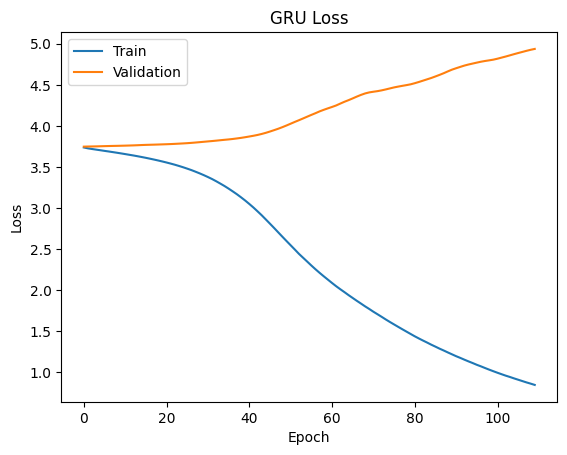

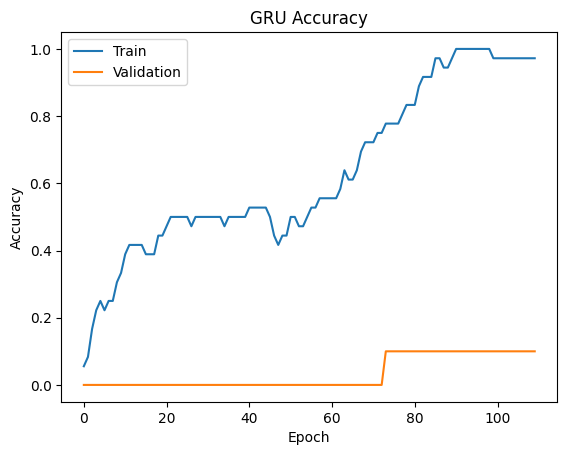

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

> ## Predicted Word Probability Distribution

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


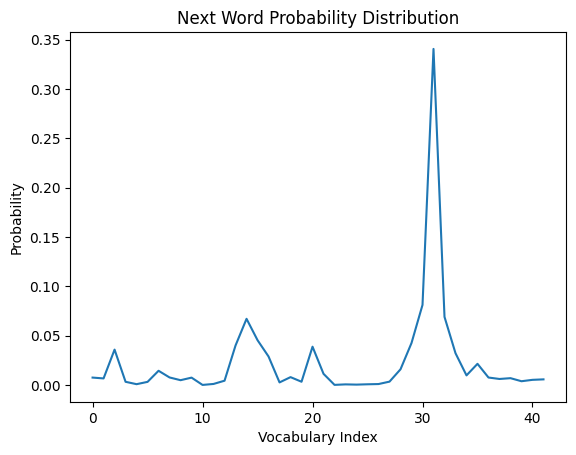

In [23]:
# probablity of a next word
import numpy as np
import matplotlib.pyplot as plt

seq = tokenized.texts_to_sequences(["deep learning"])[0]
seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')

probs = model.predict(seq)[0]

plt.figure()
plt.plot(probs)
plt.title("Next Word Probability Distribution")
plt.xlabel("Vocabulary Index")
plt.ylabel("Probability")
plt.show()

> ## Embedding Space Visualization

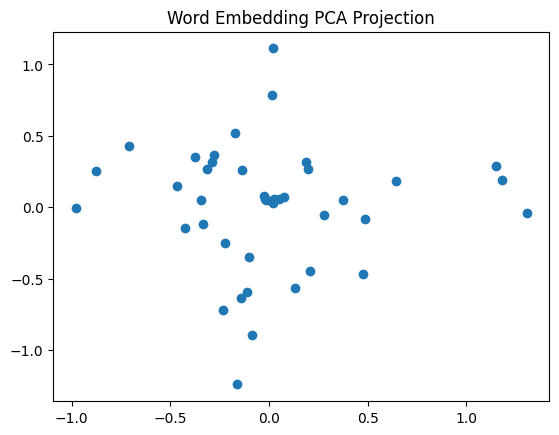

In [24]:
from sklearn.decomposition import PCA

embedding_matrix = model.layers[0].get_weights()[0]

pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_matrix[:100])

plt.figure()
plt.scatter(reduced[:,0], reduced[:,1])
plt.title("Word Embedding PCA Projection")
plt.show()